# Customer Churn Prediction using Machine Learning

## Objective

Predict whether a customer will churn based on demographic, contract, service usage, and billing information.

## Dataset

Telco Customer Churn Dataset

## Algorithms

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost (Optional)

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

## Developed By

Zahid Shaikh

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [6]:
df = pd.read_csv("../data/processed/customer_churn_cleaned.csv")

In [7]:
df.shape

(7032, 21)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [10]:
df = df.drop("customerID", axis=1)

In [11]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [13]:
X.shape

(7032, 19)

In [14]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [15]:
y[:10]

array([0, 0, 1, 0, 1, 1, 0, 0, 1, 0])

In [16]:
categorical_columns = X.select_dtypes(include="object").columns

print(categorical_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [17]:
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

In [18]:
X.shape

(7032, 30)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (5625, 30)
Testing Set : (1407, 30)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X_train[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)

X_test[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)

In [22]:
X_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1408,0,1.321816,0.981556,1.659900,True,True,True,True,False,True,...,False,False,False,False,False,True,False,True,False,False
6992,0,-0.267410,-0.971546,-0.562252,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
3349,0,1.444064,0.837066,1.756104,False,True,False,True,False,True,...,False,False,False,False,False,True,False,True,False,False
4486,0,-1.204646,0.641092,-0.908326,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
3535,0,0.669826,-0.808787,-0.101561,False,True,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False


In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [25]:
y_pred = logistic_model.predict(X_test)

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.8045486851457001
Precision: 0.6504559270516718
Recall   : 0.5721925133689839
F1 Score : 0.6088193456614509


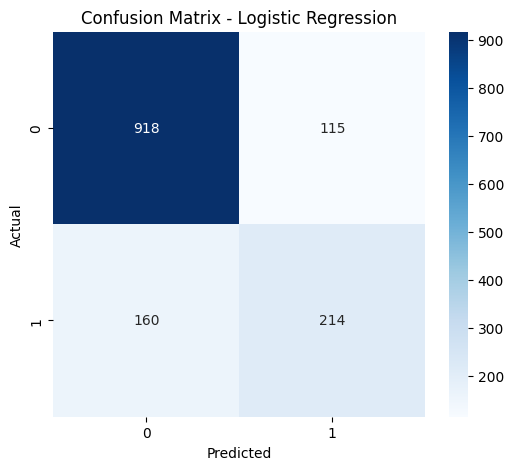

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Decision Tree Classifier

A Decision Tree learns a series of decision rules from the data. It is easy to interpret and can capture non-linear relationships between features and customer churn.

In [28]:
from sklearn.tree import DecisionTreeClassifier

In [29]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [30]:
dt_pred = decision_tree.predict(X_test)

In [31]:
from sklearn.metrics import roc_auc_score

In [32]:
print("Accuracy :", round(accuracy_score(y_test, dt_pred),4))
print("Precision:", round(precision_score(y_test, dt_pred),4))
print("Recall   :", round(recall_score(y_test, dt_pred),4))
print("F1 Score :", round(f1_score(y_test, dt_pred),4))
print("ROC AUC  :", round(roc_auc_score(y_test, dt_pred),4))

Accuracy : 0.7783
Precision: 0.5807
Recall   : 0.5963
F1 Score : 0.5884
ROC AUC  : 0.7202


In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [34]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



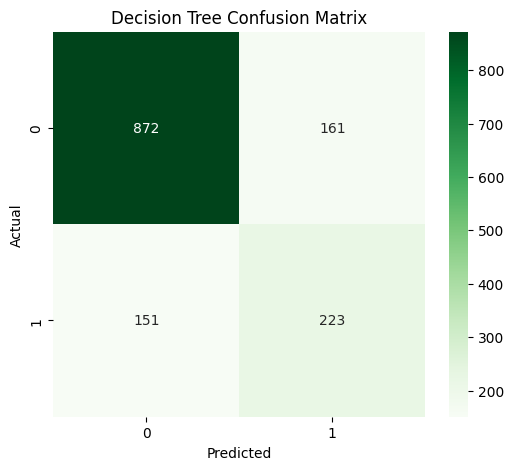

In [35]:
cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Random Forest Classifier

Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is widely used for customer churn prediction because it performs well on structured business data.

In [36]:
from sklearn.ensemble import RandomForestClassifier

In [37]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [38]:
rf_pred = random_forest.predict(X_test)

In [39]:
print("Accuracy :", round(accuracy_score(y_test, rf_pred),4))
print("Precision:", round(precision_score(y_test, rf_pred),4))
print("Recall   :", round(recall_score(y_test, rf_pred),4))
print("F1 Score :", round(f1_score(y_test, rf_pred),4))
print("ROC AUC  :", round(roc_auc_score(y_test, rf_pred),4))

Accuracy : 0.7882
Precision: 0.6234
Recall   : 0.5134
F1 Score : 0.563
ROC AUC  : 0.7005


In [40]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



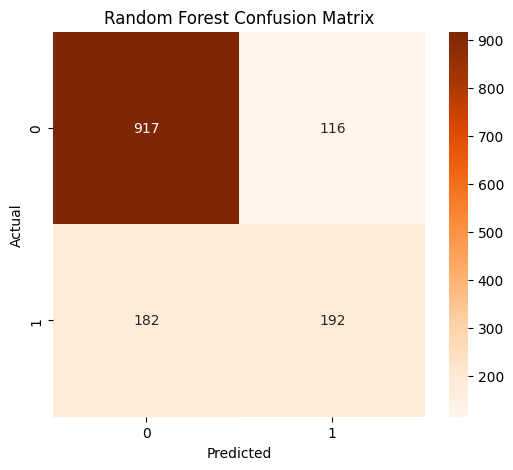

In [41]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
   annot=True,
   fmt="d",
   cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [42]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.804549,0.650456,0.572193,0.608819
1,Decision Tree,0.778252,0.580729,0.596257,0.588391
2,Random Forest,0.788202,0.623377,0.513369,0.563050


In [43]:
comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.804549,0.650456,0.572193,0.608819
2,Random Forest,0.788202,0.623377,0.513369,0.563050
1,Decision Tree,0.778252,0.580729,0.596257,0.588391


In [44]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic_model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient
10,InternetService_Fiber optic,1.121685
3,TotalCharges,0.641811
28,PaymentMethod_Electronic check,0.386286
21,StreamingTV_Yes,0.374880
9,MultipleLines_Yes,0.362680
23,StreamingMovies_Yes,0.347601
26,PaperlessBilling_Yes,0.290723
0,SeniorCitizen,0.195363
29,PaymentMethod_Mailed check,0.076969
17,DeviceProtection_Yes,0.073764


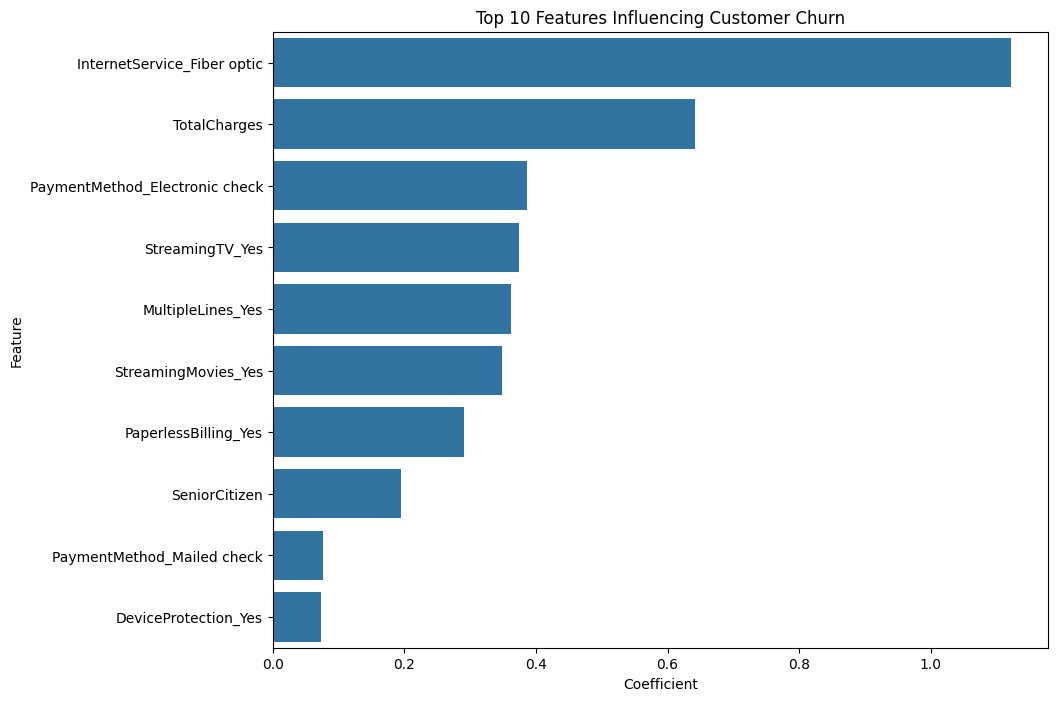

In [45]:
plt.figure(figsize=(10,8))

top_features = feature_importance.head(10)

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Features Influencing Customer Churn")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

In [46]:
import os

print(os.getcwd())

c:\Users\HP\OneDrive\Desktop\Projects\Customer-Retention-Intelligence-Platform\notebooks


In [54]:
print(os.path.exists("../models/trained_models"))
print(os.path.exists("../models/scalers"))
print(os.path.exists("../models/encoders"))

True
True
True


In [48]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nNotebook parent:")
print(Path.cwd().parent)

print("\nModels folder exists:")
print((Path.cwd().parent / "models").exists())

print("\ntrained_models exists:")
print((Path.cwd().parent / "models" / "trained_models").exists())

print("\nAbsolute path:")
print(Path.cwd().parent / "models" / "trained_models" / "churn_model.pkl")

Current working directory:
c:\Users\HP\OneDrive\Desktop\Projects\Customer-Retention-Intelligence-Platform\notebooks

Notebook parent:
c:\Users\HP\OneDrive\Desktop\Projects\Customer-Retention-Intelligence-Platform

Models folder exists:
True

trained_models exists:
True

Absolute path:
c:\Users\HP\OneDrive\Desktop\Projects\Customer-Retention-Intelligence-Platform\models\trained_models\churn_model.pkl


In [49]:
type(logistic_model)

sklearn.linear_model._logistic.LogisticRegression

In [55]:
from pathlib import Path

project_path = Path.cwd().parent

print(project_path)

c:\Users\HP\OneDrive\Desktop\Projects\Customer-Retention-Intelligence-Platform


In [56]:
from pathlib import Path

model_dir = project_path / "models" / "trained_models"
scaler_dir = project_path / "models" / "scalers"
encoder_dir = project_path / "models" / "encoders"

print(model_dir)
print(model_dir.exists())

print(scaler_dir)
print(scaler_dir.exists())

print(encoder_dir)
print(encoder_dir.exists())

c:\Users\HP\OneDrive\Desktop\Projects\Customer-Retention-Intelligence-Platform\models\trained_models
True
c:\Users\HP\OneDrive\Desktop\Projects\Customer-Retention-Intelligence-Platform\models\scalers
True
c:\Users\HP\OneDrive\Desktop\Projects\Customer-Retention-Intelligence-Platform\models\encoders
True


In [58]:
import joblib

joblib.dump(
    logistic_model,
    model_dir / "churn_model.pkl"
)

joblib.dump(
    scaler,
    scaler_dir / "scaler.pkl"
)

joblib.dump(
    label_encoder,
    encoder_dir / "label_encoder.pkl"
)

print("✅ Saved Successfully")

✅ Saved Successfully


In [59]:
joblib.dump(
    scaler,
    "../models/scalers/scaler.pkl"
)

joblib.dump(
    label_encoder,
    "../models/encoders/label_encoder.pkl"
)

['../models/encoders/label_encoder.pkl']

In [60]:
import os

print(os.listdir("../models/trained_models"))
print(os.listdir("../models/scalers"))
print(os.listdir("../models/encoders"))

['churn_model.pkl']
['scaler.pkl']
['label_encoder.pkl']
